<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/depmap/04_secici_bagimliliklar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seçici bağımlılıklar

Projenin kalbi. 4.2'de genleri medyan ve değişkenlik haritasına yerleştirmiştik; 4.3'te tek bir genin nasıl seçici davrandığını gördük. Bu defterde soruyu tersine çeviriyoruz: elimizde 5.000 gen var, hangileri KRAS gibi davranıyor?

Aradığımız profil şu: bir grup hatta ölümcül, geri kalanında etkisiz. Ne her yerde ölümcül (ortak esansiyeller — 4.2'de gördüğümüz gibi kötü hedefler), ne de hiçbir yerde etkili.

In [1]:
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

KOK = 'https://zenodo.org/records/22759375/files'
urllib.request.urlretrieve(f'{KOK}/depmap_ders_skorlar%20(1).csv?download=1', 'skorlar.csv')
urllib.request.urlretrieve(f'{KOK}/depmap_ders_kunye%20(1).csv?download=1', 'kunye.csv')

skor = pd.read_csv('skorlar.csv', index_col=0)
kunye = pd.read_csv('kunye.csv', index_col=0)
print(skor.shape, kunye.shape)

(1208, 5000) (1208, 3)


## 1. Seçicilik ölçütü

Ölçütü üç koşulla kuruyoruz ve her birinin gerekçesi var:

1. **Bağımlı hat sayısı en az 10**: bir gen yalnız 2-3 hatta ölümcülse bu bir aykırı değer olabilir; ilaç geliştirmek için de yeterince geniş bir hasta grubu yoktur.
2. **Bağımlı hat oranı %40'ın altında**: oran bunun üstüne çıkarsa gen ortak esansiyele yaklaşır ve terapötik pencere kapanır.
3. **Bağımlı olmayan hatlarda medyan skor −0,25'in üstünde**: bu, "geri kalan hatlar gerçekten umursamıyor" koşulu. Olmazsa, her yerde biraz ölümcül olan genler de listeye sızar.

Eşiklerin hepsi karardır, veri özelliği değil; raporda yazılırlar.

In [2]:
ESIK = -1.0
altinda = skor < ESIK
n_bagimli = altinda.sum()
oran = altinda.mean()

bagimsiz_medyan = skor.where(~altinda).median()   # yalnız bağımlı olmayan hatlar

ozet = pd.DataFrame({
    'sembol': [c.split(' ')[0] for c in skor.columns],
    'n_bagimli': n_bagimli,
    'oran': oran.round(3),
    'kalan_medyan': bagimsiz_medyan.round(3),
    'medyan': skor.median().round(3),
})

secici = ozet[(ozet.n_bagimli >= 10) & (ozet.oran < 0.40) & (ozet.kalan_medyan > -0.25)]
print('seçici bağımlılık adayı:', len(secici), '/', len(ozet))
print(secici.sort_values('n_bagimli', ascending=False).head(20).to_string(index=False))

seçici bağımlılık adayı: 297 / 5000
sembol  n_bagimli  oran  kalan_medyan  medyan
 EFR3A        152 0.126        -0.248  -0.316
NMNAT1        139 0.115        -0.235  -0.266
  KLF5        133 0.110        -0.220  -0.250
  STX4        124 0.103        -0.208  -0.238
  CBFB        107 0.089        -0.132  -0.160
 STAG2         99 0.082        -0.231  -0.274
 CYB5B         89 0.074        -0.223  -0.245
 ELMO2         84 0.070        -0.203  -0.223
SLC7A5         80 0.066        -0.202  -0.231
 CCND3         79 0.065        -0.236  -0.251
 HNF1B         78 0.065        -0.150  -0.164
MTHFD1         77 0.064        -0.231  -0.252
  PMM2         76 0.063        -0.232  -0.260
CTNNB1         72 0.060        -0.130  -0.140
PTDSS1         70 0.058        -0.219  -0.237
STXBP3         68 0.056        -0.240  -0.259
  BRAF         60 0.050        -0.085  -0.092
  IRF4         59 0.049        -0.098  -0.105
 KEAP1         57 0.047        -0.118  -0.138
  TSC2         57 0.047        -0.039  -0.06

## 2. Haritada nerede duruyorlar

4.2'nin medyan-standart sapma haritasını yeniden çizip seçici adayları üzerine işaretliyoruz. Beklenen konum: sağda (medyan sıfıra yakın, çünkü hatların çoğu umursamıyor) ama yukarıda (standart sapma yüksek, çünkü bir grup hat çok aşağıda).

Bu resim projenin özetidir: iyi hedefler sol alt köşede değil, sağ üst bölgede aranır.

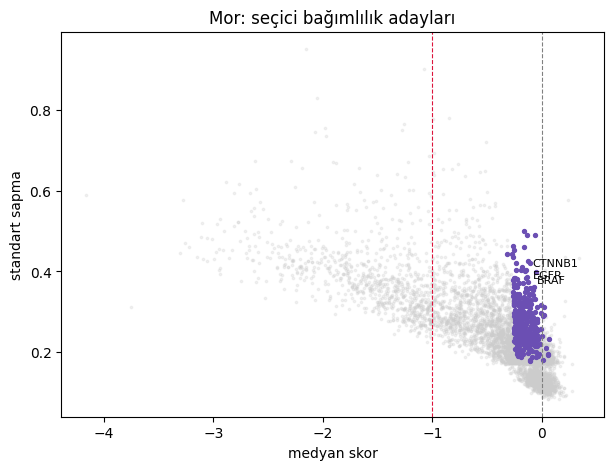

In [3]:
m = skor.median(); s = skor.std()
plt.figure(figsize=(7, 5))
plt.scatter(m, s, s=3, alpha=0.25, color='#CCCCCC')
plt.scatter(m[secici.index], s[secici.index], s=8, color='#6B4FB3')
for g in ['KRAS', 'BRAF', 'EGFR', 'CTNNB1', 'SOX10']:
    c = [x for x in skor.columns if x.split(' ')[0] == g]
    if c and c[0] in secici.index:
        plt.annotate(g, (m[c[0]], s[c[0]]), fontsize=8,
                     textcoords='offset points', xytext=(4, 3))
plt.axvline(0, ls='--', lw=0.8, c='gray'); plt.axvline(-1, ls='--', lw=0.8, c='crimson')
plt.xlabel('medyan skor'); plt.ylabel('standart sapma')
plt.title('Mor: seçici bağımlılık adayları');

## 3. Her adayın adresi

Bir seçici bağımlılık ancak bağımlı hatların ortak bir özelliği varsa kullanışlıdır. En basit ortak özellik dokudur: aday genin bağımlı hatları belirli bir dokuda mı toplanıyor?

Aşağıdaki hücre, en çok bağımlı hattı olan 15 aday için bağımlılığın en yoğunlaştığı dokuyu ve o dokudaki oranı buluyor. 4.3'ün kuralı geçerli: oran, ham sayı değil — ve en az 20 hattı olan dokularla sınırlıyoruz.

In [4]:
doku = kunye['OncotreeLineage']
buyuk_doku = doku.value_counts()[lambda x: x >= 20].index

satir = []
for c in secici.sort_values('n_bagimli', ascending=False).head(15).index:
    b = skor.index[skor[c] < ESIK]
    o = (doku[doku.isin(buyuk_doku)].loc[lambda d: d.index.isin(b)].value_counts()
         / doku.value_counts()).dropna().sort_values(ascending=False)
    if len(o):
        satir.append((c.split(' ')[0], int(secici.n_bagimli[c]), o.index[0], round(100*o.iloc[0], 1)))

print(pd.DataFrame(satir, columns=['gen', 'bagimli_hat', 'en_yogun_doku', 'oran_%']).to_string(index=False))

   gen  bagimli_hat     en_yogun_doku  oran_%
 EFR3A          152          Pancreas    37.5
NMNAT1          139          Lymphoid    68.8
  KLF5          133             Bowel    46.0
  STX4          124            Breast    26.4
  CBFB          107           Myeloid    64.4
 STAG2           99           Myeloid    31.1
 CYB5B           89           Myeloid    28.9
 ELMO2           84             Liver    32.0
SLC7A5           80           Myeloid    17.8
 CCND3           79          Lymphoid    41.7
 HNF1B           78            Kidney    60.0
MTHFD1           77          Lymphoid    27.1
  PMM2           76          Lymphoid    24.0
CTNNB1           72             Bowel    60.3
PTDSS1           70 Esophagus/Stomach    15.9


## Kendin dene

Üç görev. Birincisi: seçici aday sayınızı ve en çok bağımlı hattı olan beş geni not edin. İkincisi: adres tablosuna bakıp bilinen kanser biyolojisiyle uyuşan en az iki satır seçin ve neden uyuştuğunu tek cümleyle yazın (örneğin bir genin melanom hatlarında yoğunlaşması). Üçüncüsü: haritadaki mor noktaların konumuna bakıp tek cümleyle açıklayın — ilaç hedefi ararken neden sol alt köşeye değil sağ üst bölgeye bakıyoruz?